# Using the Google Gemini API

In this project we will use Google's Gemini free API for several different predictive and generative tasks. 

### Install and Import Packages

In [ ]:
### First install the google-genai and other packages if you have not

!pip install -q -U google-genai
!pip install -q -U pypdf
!pip install -q -U scikit-learn
!pip install -q -U pandas
!pip install -q -U matplotlib

In [ ]:
from google import genai
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pypdf import PdfReader
import random
import time
import re

random.seed(1337)

# Put your Google API Key here. Do not share or publish this online (especially if you have a paid account)
api_key = 

### Setup the Gemini Client API

First, we must initialize the Gemini client API and verify the connection with a test prompt.

This tutorial will use Gemini 2.5 Flash. Google offers many different models, but this is a free model that is often available for use.

This is an older model (June 2025), but will work well for straightforward tasks. For complex tasks, newer models will likely perform better.

One thing to keep in mind is that with a free account, sometimes errors are thrown at high traffic times of day.

In [3]:
# Initialize the Gemini client
client = genai.Client(api_key = api_key)

# Test the connection with a simple prompt
response = client.models.generate_content(
    model = "gemini-2.5-flash",
    contents = "Say hello"
)
print(response.text)

Hello!


# Example 1: Text Classification

The first example uses the Gemini API for binary text classification.

### Visualizing Text Dataset

Here, we load and preview the Spotify review data. This is 51,000+ user reviews scraped from the Google Play Store at the start of 2022.

The dataset is simple. It has two columns including "review," which consists of the review text, and "label" which denotes whether the text has positive or negative sentiment.

This dataset can be found on Kaggle: www.kaggle.com/datasets/alexandrakim2201/spotify-dataset

In [ ]:
# Load the Spotify reviews dataset and inspect its shape and label distribution
df = pd.read_csv(f"spotify_data.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
df.head(10)

Dataset shape: (52702, 2)

Label distribution:
label
NEGATIVE    29423
POSITIVE    23279
Name: count, dtype: int64


,Review,label
0,"Great music service, the audio is high quality...",POSITIVE
1,Please ignore previous negative rating. This a...,POSITIVE
2,"This pop-up ""Get the best Spotify experience o...",NEGATIVE
3,Really buggy and terrible to use as of recently,NEGATIVE
4,Dear Spotify why do I get songs that I didn't ...,NEGATIVE
5,The player controls sometimes disappear for no...,NEGATIVE
6,I love the selection and the lyrics are provid...,POSITIVE
7,Still extremely slow when changing storage to ...,NEGATIVE
8,It's a great app and the best mp3 music app I ...,POSITIVE
9,"I'm deleting this app, for the following reaso...",NEGATIVE



 Review Length (Words):
count    52686.0
mean        28.5
std         22.8
min          1.0
25%         11.0
50%         22.0
75%         39.0
max        423.0
Name: review_length, dtype: float64

 Review Length By label:
label
NEGATIVE    35.9
POSITIVE    19.1
Name: review_length, dtype: float64

 Top 20 Words Overall:
  music           21359
  you             16920
  spotify         15293
  songs           14455
  song            12058
  play            9395
  like            7988
  good            7791
  love            7753
  when            7686
  listen          7407
  all             7348
  premium         6993
  ads             6712
  great           6205
  playlist        5650
  even            5382
  now             5345
  playing         5328
  want            4946

 Top 10 Words — Positive Reviews:
  music           11548
  spotify         6283
  you             6230
  love            5739
  good            4861
  songs           4537
  great           4129
  best         

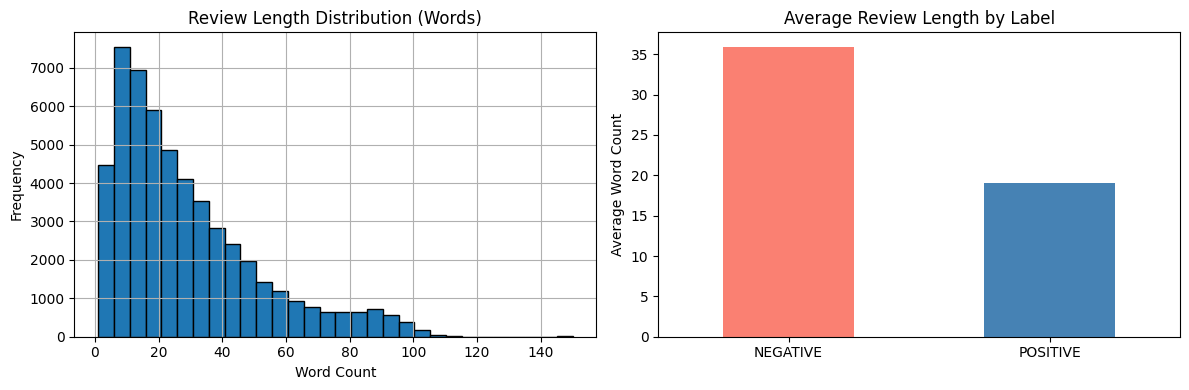

In [4]:
# Calculate Average Review Length
df["review_length"] = df["Review"].str.split().str.len()

print("\n Review Length (Words):")
print(df["review_length"].describe().round(1))

print("\n Review Length By label:")
print(df.groupby("label")["review_length"].mean().round(1))

# Function to Get Most Common Words 
# Input is a column of text data, and n is the number of top words to return
def get_top_words(series, n = 20):
    stopwords = {"the","a","an","and","is","it","i","to","of","in","for",
                 "my","this","on","was","with","that","but","so","not","have",
                 "are","its","be","at","as","has","me","app","it's","just","very","can"}
    words = re.findall(r'\b[a-z]+\b', " ".join(series.dropna().str.lower())) # Extracts all words
    filtered = [w for w in words if w not in stopwords and len(w) > 2] # Removes stopwords from the top words list
    return Counter(filtered).most_common(n)

print("\n Top 20 Words Overall:")
for word, count in get_top_words(df["Review"]):
    print(f"  {word:<15} {count}")

print("\n Top 10 Words — Positive Reviews:")
for word, count in get_top_words(df[df["label"] == "POSITIVE"]["Review"], n = 10):
    print(f"  {word:<15} {count}")

print("\n Top 10 Words — Negative Reviews:")
for word, count in get_top_words(df[df["label"] == "NEGATIVE"]["Review"], n = 10):
    print(f"  {word:<15} {count}")

# Distribution Plots of Review Lengths and Average Length by Label
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

df["review_length"].clip(upper = 150).hist(bins = 30, ax = axes[0], edgecolor = "black") # Clip length at 150 words max
axes[0].set_title("Review Length Distribution (Words)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")

df.groupby("label")["review_length"].mean().plot(kind = "bar", ax = axes[1], color = ["salmon", "steelblue"])
axes[1].set_title("Average Review Length by Label")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average Word Count")
axes[1].tick_params(axis = 'x', rotation = 0)

plt.tight_layout()
plt.show()

### Using the Gemini API for Text Classification

Next, we will use Gemini to classify Spotify reviews as positive or negative. 

We'll sample just a handful of reviews to keep API usage manageable, then compare Gemini's predictions against the ground-truth labels.

In [ ]:
# Sample 5 reviews for classification
sample_df = df.sample(n = 5, random_state = 1337).reset_index(drop = True)

# Define a function to classify reviews using Gemini
# Different prompts will produce different results, so you may need to experiment with the wording and formatting to see how it affects the predictions for your task
def classify_review(review_text):
    prompt = f"""Classify the following app review as either POSITIVE or NEGATIVE.
    Respond with exactly one word: POSITIVE or NEGATIVE.

    Review: \"\"\"{review_text}\"\"\"

    Classification:"""

    response = client.models.generate_content(
        model = "gemini-2.5-flash",
        contents = prompt,
    )
    return response.text.strip()

# Loop through and classify each review by calling the function
predictions = []
for i, row in sample_df.iterrows():
    pred = classify_review(row["Review"])
    predictions.append(pred)
    print(f"[{i+1}/5] Review: {row['Review'][:120]}\n Predicted: {pred:10s} | Actual: {row['label']}\n")
    time.sleep(1.0)  # rate-limit courtesy

sample_df["predicted"] = predictions

[1/5] Review: I would have given 5 stars if the duo Playlist actually worked.
 Predicted: NEGATIVE   | Actual: NEGATIVE

[2/5] Review: It doesn't work well on my Roku TV, so I cast it from my phone.
 Predicted: NEGATIVE   | Actual: NEGATIVE

[3/5] Review: Its amazing if you get it on TV or have 20 a month but other than that it is amazing
 Predicted: POSITIVE   | Actual: POSITIVE

[4/5] Review: I can't see and control album tracks .. it only shuffles! Is this because i am in free trail. It's so annoying.
 Predicted: NEGATIVE   | Actual: NEGATIVE

[5/5] Review: I love listening to music on Spotify
 Predicted: POSITIVE   | Actual: POSITIVE



### Assessing the Predictive Performance for the Classification Task

Once we field predictions, we need a way to quantify how well our model performs.

There are many ways to do this, with the most straightforward being accuracy (% of predictions that are correct).

However, there are other metrics such as the F1 score, area under the curve - precision recall (AUC-PR), or the receiving operator characteristic - area under the curve (ROC-AUC). ROC-AUC and AUC-PR require predicted probability scores, which Gemini is not configured to produce in this notebook.

These metrics provide greater information using measures such as precision & recall or sensitivity & specificity, and some are robust to class imbalance.

Accuracy: 100.0% (5/5 correct)

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       1.00      1.00      1.00         3
    POSITIVE       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



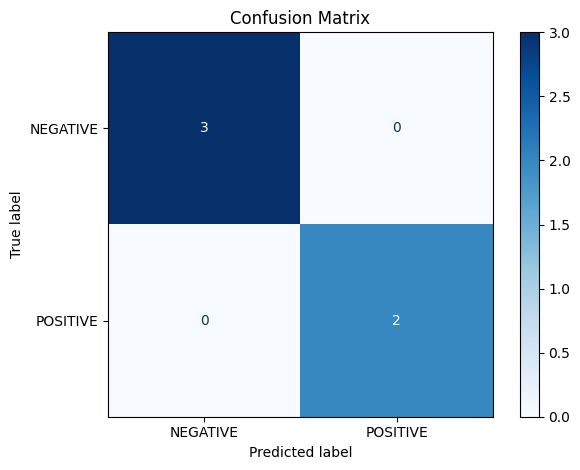

Full Results Table:
                                                                            Review     label predicted
0                  I would have given 5 stars if the duo Playlist actually worked.  NEGATIVE  NEGATIVE
1                  It doesn't work well on my Roku TV, so I cast it from my phone.  NEGATIVE  NEGATIVE
2  Its amazing if you get it on TV or have 20 a month but other than that it is...  POSITIVE  POSITIVE
3  I can't see and control album tracks .. it only shuffles! Is this because i ...  NEGATIVE  NEGATIVE
4                                             I love listening to music on Spotify  POSITIVE  POSITIVE


In [ ]:
# Compare predictions to ground truth
accuracy = (sample_df["predicted"] == sample_df["label"]).mean()
print(f"Accuracy: {accuracy:.1%} ({int(accuracy * 5)}/5 correct)\n")

# Classification report
print("Classification Report:")
print(classification_report(sample_df["label"], sample_df["predicted"], target_names = ["NEGATIVE", "POSITIVE"]))

# Confusion matrix
cm = confusion_matrix(sample_df["label"], sample_df["predicted"], labels = ["NEGATIVE", "POSITIVE"])
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["NEGATIVE", "POSITIVE"])
disp.plot(cmap = "Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Show the full results table
print("Full Results Table:")
print(sample_df[["Review", "label", "predicted"]].to_string(max_colwidth = 80))

# Example 2: Read and Summarize PDFs

The second example uses the Gemini API to read and summarize PDF text.

### Examining PDF Attributes

Here, we load and examine the structure of President Lincoln's "Preliminary Emancipation Proclamation." 

This is not the "popular" emancipation proclamation, rather its the 1862 warning to the Confederacy to cease their rebellion.

In [12]:
# Define a function to examine the PDF and extract the structure including page count, empty pages, character counts, and top words
def examine_pdf(path):
    reader = PdfReader(path)
    n_pages = len(reader.pages)

    page_text = []
    for i, p in enumerate(reader.pages, start = 1): # Loop through pages and extract text
        txt = p.extract_text() or ""
        page_text.append((i, txt))

    char_counts = [len(t) for _, t in page_text] # Count characters on each page
    empty_pages = [i for i, t in page_text if len(t.strip()) == 0] # Identify empty pages

    full_text = "\n".join(t for _, t in page_text).lower() # Combine all text for word frequency analysis
    stopwords = {"the","a","an","and","is","it","i","to","of","in","for",
                "my","this","on","was","with","that","but","so","not","have", "or", "by",
                "are","its","be","at","as","has","me","app","it's","just","very","can"}
    words = re.findall(r"\b[a-z']+\b", full_text) # Extract all words
    word_counts = len(words) / n_pages if n_pages > 0 else 0 # Average words per page
    filtered_words = [w for w in words if w not in stopwords] # Remove stop words
    top_words = Counter(filtered_words).most_common(10) # Extract top 10 words

    # Create a final report summary
    report = {
        "pages": n_pages,
        "empty_pages": empty_pages,
        "avg_chars_per_page": round(sum(char_counts) / max(n_pages, 1), 1),
        "avg_words_per_page": round(word_counts, 1),
        "top_words": top_words,
    }
    return report

pdf_path = "preliminary_emancipation_proclamation.pdf" # Define file path

analysis = examine_pdf(pdf_path) # Call function

print("PDF Preliminary Analysis:")
print(f"pages: {analysis['pages']}")
print(f"empty pages: {analysis['empty_pages']}")
print(f"avg chars per page: {analysis['avg_chars_per_page']}")
print(f"avg words per page: {analysis['avg_words_per_page']}")
print("-" * 40)
print("\nTop words:")
for w, c in analysis["top_words"]: # Extract tuple information; w is word, c is count
    print(f"  {w:<15} {c}")

PDF Preliminary Analysis:
pages: 2
empty pages: []
avg chars per page: 3163.5
avg words per page: 534.0
----------------------------------------

Top words:
  states          30
  united          23
  shall           21
  any             18
  persons         11
  such            11
  service         10
  all             9
  from            9
  rebellion       8


### Using the Gemini API for PDF Summarization 

Next, we will use Gemini to request a 5-bullet summary of the PDF.

In [13]:
# Upload the PDF
pdf = client.files.upload(file = "preliminary_emancipation_proclamation.pdf")

# Craft a prompt to summarize the PDF
prompt = """
Summarize this PDF for a general audience.
Return:
1) key topics
2) 5-bullet summary including important numbers and dates
"""

# Call the model with the PDF and a prompt
response = client.models.generate_content(
    model = "gemini-2.5-flash",
    contents = [pdf, prompt], # This can be a list like here, or a single string if you just want to send text
)
print(response.text)

Here's a summary of the Preliminary Emancipation Proclamation for a general audience:

**1) Key Topics:**

*   **Conditional Emancipation:** The announcement of a future declaration of freedom for enslaved people in Confederate territories.
*   **War Aims:** Redefining the Union's objectives to include ending slavery in rebellious states, while still primarily focused on restoring the Union.
*   **Congressional Backing:** Reinforcement of existing laws passed by Congress regarding the status of enslaved people and the military's role.
*   **Compensation and Colonization:** Provisions for potentially compensating loyal slave owners and continuing efforts to resettle freed African Americans outside the U.S.

**2) 5-Bullet Summary:**

*   Issued on **September 22, 1862**, by President Abraham Lincoln, this proclamation declared that if Confederate states were still in rebellion by **January 1, 1863**, all enslaved people in those rebellious areas would be declared "thenceforward, and fore

# Example 3: Sentiment Analysis from Text Data

The third example analyzes sentiment from text data.

### Visualizing Text Dataset

Here, we load and preview social media data. This is 500 posts across Facebook, Twitter, and Instagram.

The dataset has a bunch of meta data including when the post was made. We are interested in the "text" and "sentiment" columns.

The text column is the text of the social media post. The sentiment column is a label that denotes whether the post is positive, neutral, or negative.

Dataset shape: (499, 7)

Label distribution:
sentiment
NEUTRAL     199
POSITIVE    166
NEGATIVE    134
Name: count, dtype: int64
                                                                                                                text sentiment
                                                                                     just got up and updated my ipod   NEUTRAL
                                                                                Bouncing Rush makes me feel nauseous  NEGATIVE
just about to go home. I`m usually `mr. positive` but this has been one of those daze. well, 15 mins until tomorrow!   NEUTRAL
 _x_ATL u mean jack barakat`s?! wow so have u ever gone to his house? Hehe i mean ur ssoo lucky to have the address!  POSITIVE
                                                                                         juss came back from Barisal   NEUTRAL


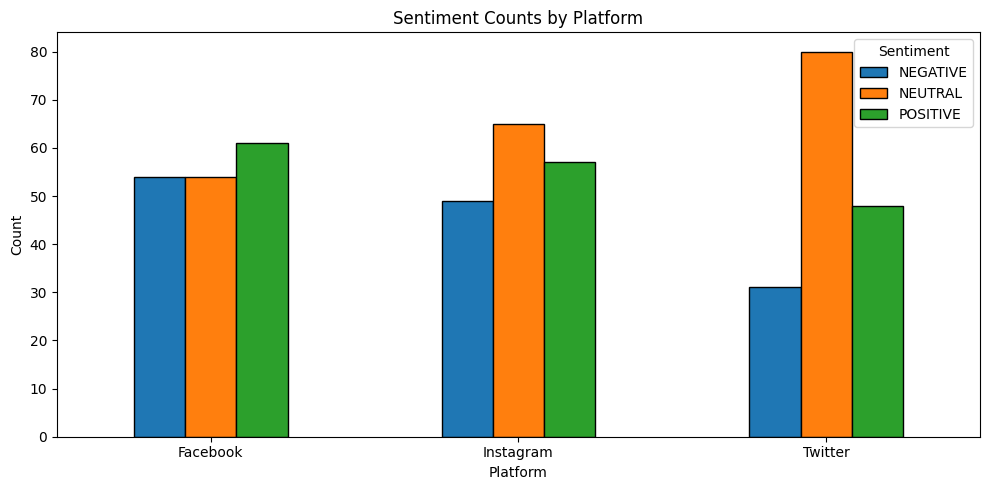

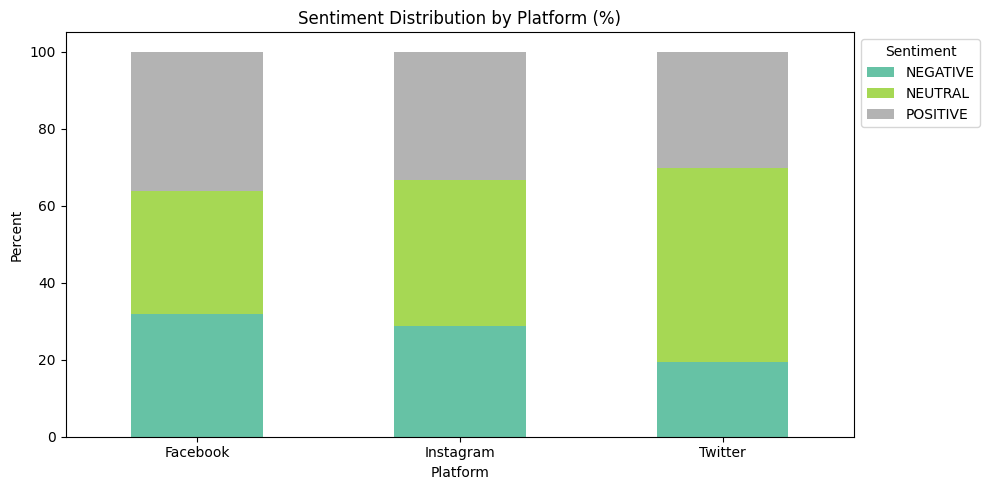

In [17]:
# Load sentiment dataset and examine shape
sent_df = pd.read_csv(f"sentiment_analysis.csv")
sent_df = sent_df.dropna(subset = ["text", "sentiment"]).copy()
sent_df["text"] = sent_df["text"].astype(str).str.strip()
sent_df["sentiment"] = sent_df["sentiment"].astype(str).str.strip().str.upper()

print(f"Dataset shape: {sent_df.shape}")
print("\nLabel distribution:")
print(sent_df["sentiment"].value_counts())

# Examine a few samples
n = 5
work_df = sent_df.copy() if n is None else sent_df.sample(n = min(n, len(sent_df)), random_state = 1343).reset_index(drop = True)
with pd.option_context("display.max_colwidth", None, "display.width", 200):
    print(work_df[["text", "sentiment"]].to_string(index = False))

# Visualization of sentiment distribution by platform
sent_df["Platform"] = sent_df["Platform"].astype(str).str.strip().str.title()

# Count of sentiment labels by platform
count_table = pd.crosstab(sent_df["Platform"], sent_df["sentiment"])
count_table.plot(kind = "bar", figsize = (10, 5), edgecolor = "black")
plt.title("Sentiment Counts by Platform")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.xticks(rotation = 0)
plt.legend(title = "Sentiment")
plt.tight_layout()
plt.show()

# Percentage distribution by platform (each platform sums to 100%)
pct_table = pd.crosstab(sent_df["Platform"], sent_df["sentiment"], normalize = "index") * 100
pct_table.plot(kind = "bar", stacked = True, figsize = (10, 5), colormap = "Set2")
plt.title("Sentiment Distribution by Platform (%)")
plt.xlabel("Platform")
plt.ylabel("Percent")
plt.xticks(rotation = 0)
plt.legend(title = "Sentiment", bbox_to_anchor = (1, 1), loc = "upper left")
plt.tight_layout()
plt.show()

### Using the Gemini API for Sentiment Analysis

Next, we will classify the sentiment of social media posts. 

Our three labels will be positive, neutral, and negative.

[1/5] Predicted: NEUTRAL  | Actual: NEUTRAL
[2/5] Predicted: NEGATIVE | Actual: NEGATIVE
[3/5] Predicted: NEGATIVE | Actual: NEUTRAL
[4/5] Predicted: POSITIVE | Actual: POSITIVE
[5/5] Predicted: NEUTRAL  | Actual: NEUTRAL

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE      0.500     1.000     0.667         1
     NEUTRAL      1.000     0.667     0.800         3
    POSITIVE      1.000     1.000     1.000         1

    accuracy                          0.800         5
   macro avg      0.833     0.889     0.822         5
weighted avg      0.900     0.800     0.813         5



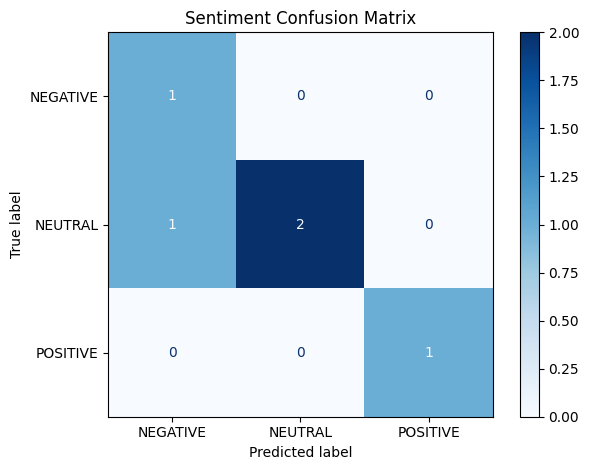

In [15]:
# This prompt could be improved by adding specific codebook instructions for each label
def classify_sentiment(text):
    prompt = f"""Classify the sentiment of this text as one of: POSITIVE, NEGATIVE, or NEUTRAL.

    Return exactly one label in ALL CAPS, with one word and no explanation.

    Text: \"\"\"{text}\"\"\"

    Label:"""

    response = client.models.generate_content(
        model = "gemini-2.5-flash",
        contents = prompt
    )
    raw = response.text.strip().upper()

    # Keep only valid label
    if "POSITIVE" in raw:
        return "POSITIVE"
    if "NEGATIVE" in raw:
        return "NEGATIVE"
    if "NEUTRAL" in raw:
        return "NEUTRAL"
    return "NA"

# Call function and classify
preds = []
for i, row in work_df.iterrows():
    pred = classify_sentiment(row["text"])
    preds.append(pred)
    print(f"[{i+1}/{len(work_df)}] Predicted: {pred:8s} | Actual: {row['sentiment']}")
    time.sleep(1.0)

work_df["predicted"] = preds

# Evaluate
print("\nClassification Report:")
print(classification_report(work_df["sentiment"], work_df["predicted"], digits = 3))

labels = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
cm = confusion_matrix(work_df["sentiment"], work_df["predicted"], labels = labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
disp.plot(cmap = "Blues")
plt.title("Sentiment Confusion Matrix")
plt.tight_layout()
plt.show()